# Differential expression + enrichment between groups (IFN_gamma hotspot cells)

What stands out in the **abscopal** tumor (group **B**)? Mirrors `RegionComparison.ipynb`
(cell-level `rank_genes_groups` + Enrichr), but the "regions" are the conditions A/B/C, and it
adds a **DESeq2 pseudobulk** track that respects the replicate structure.

> **Run this with the `spatial_cpu_py311` kernel** (has `pydeseq2` + `gseapy`).

**Contrasts** (test vs reference): **B vs C** (abscopal vs no-RT secondary — cleanest) and
**B vs A** (abscopal vs irradiated primary). Positive LFC = **higher in B**.

**Two DE tracks**
- **Cell-level** (`rank_genes_groups`, Wilcoxon): high power, but **pseudoreplicated** — for ranking.
- **Pseudobulk DESeq2** (sum counts per tissue → negative-binomial DE): the honest unit (n=4/2/4).
  With only **2 B tissues** it is **low-power and exploratory** — we lean on *direction* +
  *concordance with the cell-level ranking*, not raw padj.

`abscopal_signature` = genes up in B vs **both** A and C, cell-level **and** DESeq2-direction-concordant.

Enrichment uses **gseapy Enrichr** (online); if that fails (no internet / rate limit) it falls back
automatically to an offline hypergeometric ORA over the local GMTs.

## 1. Load data (h5ad with counts) + gene sets

In [24]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

DATA_DIR    = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/ifng_hotspot_featureset")
pathway_dir = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/references/pathways")
OUT_DIR     = DATA_DIR / "group_de_enrichment"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def read_h5ad_robust(path):
    """Load the h5ad on any anndata version (older ones choke on null-encoded uns scalars)."""
    try:
        return ad.read_h5ad(path)
    except Exception as e:
        print("plain read_h5ad failed (%s); using uns-skipping loader" % type(e).__name__)
        import h5py
        from anndata.experimental import read_dispatched
        def cb(func, name, elem, iospec):
            return {} if name == "/uns" else func(elem)
        with h5py.File(path, "r") as f:
            a = read_dispatched(f, cb)
            dec = lambda x: [v.decode() if isinstance(v, bytes) else v for v in x[...]]
            for k in ("lr_features", "ifn_gamma_genes"):
                if k in f["uns"]:
                    a.uns[k] = dec(f["uns"][k])
        return a

adata = read_h5ad_robust(DATA_DIR / "ifng_hotspot_featureset.h5ad")
assert "counts" in adata.layers, "counts layer needed for DESeq2 pseudobulk"
print(adata.shape, "| layers:", list(adata.layers.keys()))
print("groups:", adata.obs["group"].value_counts().to_dict())

def read_gmt(path):
    d = {}
    with open(path) as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 3:
                d[p[0]] = p[2:]
    return d
all_gene_sets = {}
for p in [pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
          pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
          pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt"]:
    all_gene_sets.update(read_gmt(p))
print("local gene sets (offline fallback):", len(all_gene_sets))


(224088, 19059) | layers: ['counts']
groups: {'C_noRT_secondary': 94829, 'A_RT_primary': 69233, 'B_RT_secondary': 60026}
local gene sets (offline fallback): 9164


## 2. Configuration

In [25]:
GROUP_COL, CT_COL, SAMPLE_COL = "group", "c2l_permissive", "tissue"
CONTRASTS = [("B_RT_secondary", "C_noRT_secondary"),    # abscopal vs no-RT secondary (primary)
             ("B_RT_secondary", "A_RT_primary")]        # abscopal vs irradiated primary

PADJ = 0.05
LFC  = 0.5            # cell-level log2FC threshold (scanpy)
PB_LFC = 0.5         # DESeq2 |log2FoldChange| direction threshold (padj is weak at n=2)
MIN_CELLS_CT = 50    # per (tissue, cell type) minimum to enter pseudobulk
MIN_GENE_TOTAL = 10  # drop genes with < this many summed counts before DESeq2
N_ENRICH = 300       # top up/down genes sent to enrichment
USE_GSEAPY = True    # Enrichr online; falls back to offline ORA on failure
ENRICHR_DBS = ["MSigDB_Hallmark_2020", "Reactome_2022",
               "GO_Biological_Process_2023", "KEGG_2019_Mouse"]
RUN_PER_CELLTYPE = True   # set False to skip the (slow) per-cell-type sweep

short = {"A_RT_primary": "A", "B_RT_secondary": "B", "C_noRT_secondary": "C"}
def tag(test, ref): return f"{short[test]}_vs_{short[ref]}"
print("contrasts:", [tag(t, r) for t, r in CONTRASTS], "| gseapy:", USE_GSEAPY)


contrasts: ['B_vs_C', 'B_vs_A'] | gseapy: True


## 3. Functions

In [26]:
# ---- cell-level DE (scanpy Wilcoxon on lognorm X) ----
def cell_level_de(adata, test, ref, celltype=None):
    a = adata if celltype is None else adata[adata.obs[CT_COL].astype(str) == celltype]
    a = a[a.obs[GROUP_COL].isin([test, ref])].copy()
    a.obs[GROUP_COL] = a.obs[GROUP_COL].astype(str).astype("category")
    if a.obs[GROUP_COL].nunique() < 2:
        return None
    sc.tl.rank_genes_groups(a, groupby=GROUP_COL, groups=[test], reference=ref,
                            method="wilcoxon", key_added="de")
    return sc.get.rank_genes_groups_df(a, group=test, key="de").sort_values(
        "scores", ascending=False).reset_index(drop=True)

# ---- pseudobulk: SUM raw counts per sample (optionally within a cell type) ----
def pseudobulk_counts(adata, celltype=None, min_cells=MIN_CELLS_CT):
    a = adata if celltype is None else adata[adata.obs[CT_COL].astype(str) == celltype]
    counts = a.layers["counts"]
    samples = a.obs[SAMPLE_COL].astype(str).values
    rows, idx = [], []
    for s in pd.unique(samples):
        m = samples == s
        if m.sum() < min_cells:
            continue
        rows.append(np.asarray(counts[m].sum(axis=0)).ravel()); idx.append(s)
    if not rows:
        return None, None
    pb = pd.DataFrame(rows, index=idx, columns=a.var_names.astype(str))
    grp = (a.obs.drop_duplicates(SAMPLE_COL).set_index(SAMPLE_COL)[GROUP_COL]
           .reindex(pb.index).astype(str))
    return pb, grp

# ---- DESeq2 differential expression on the pseudobulk counts ----
def deseq2_de(pb, grp, test, ref, min_total=MIN_GENE_TOTAL):
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats
    keep = grp[grp.isin([test, ref])].index
    if (grp.loc[keep] == test).sum() < 2 or (grp.loc[keep] == ref).sum() < 2:
        return None                                   # need >=2 tissues per side
    c = pb.loc[keep]
    c = c.loc[:, c.sum(axis=0) >= min_total].round().astype(int)
    meta = pd.DataFrame({"group": grp.loc[keep].astype(str).values}, index=keep)
    dds = DeseqDataSet(counts=c, metadata=meta, design="~group",
                       ref_level=["group", ref], quiet=True)
    dds.deseq2()
    st = DeseqStats(dds, contrast=["group", test, ref], quiet=True)
    st.summary()
    res = st.results_df.copy()
    res.insert(0, "names", res.index.astype(str))
    return res.reset_index(drop=True).sort_values("stat", ascending=False)

# ---- enrichment: gseapy Enrichr (online) with offline ORA fallback ----
def _ora(gene_list, gene_sets, background, min_set=5, max_set=500):
    bg = set(background); gl = set(gene_list) & bg
    N, n = len(bg), len(gl)
    rows = []
    for name, genes in gene_sets.items():
        gs = set(genes) & bg; K = len(gs)
        if K < min_set or K > max_set:
            continue
        k = len(gl & gs)
        if k < 2:
            continue
        rows.append((name, name, K, k, hypergeom.sf(k - 1, N, K, n), ",".join(sorted(gl & gs)[:12])))
    df = pd.DataFrame(rows, columns=["gene_set", "term", "set_size", "overlap", "pval", "genes"])
    if len(df):
        df["padj"] = multipletests(df["pval"], method="fdr_bh")[1]
        df = df.sort_values("padj")
    return df.reset_index(drop=True)

def run_enrichment(genes, background):
    genes = list(genes)
    if USE_GSEAPY and len(genes) >= 5:
        try:
            import gseapy as gp, time
            for attempt in range(3):
                try:
                    enr = gp.enrichr(gene_list=genes, gene_sets=ENRICHR_DBS,
                                     organism="mouse", outdir=None)
                    df = enr.results.rename(columns={
                        "Adjusted P-value": "padj", "P-value": "pval", "Term": "term",
                        "Gene_set": "gene_set", "Overlap": "overlap", "Genes": "genes"})
                    return df.sort_values("padj").reset_index(drop=True)
                except Exception as e:
                    if "429" in str(e) or "status" in str(e).lower():
                        time.sleep(5 * (attempt + 1)); continue
                    raise
        except Exception as e:
            print(f"  gseapy Enrichr failed ({type(e).__name__}: {e}); using offline ORA")
    return _ora(genes, all_gene_sets, background)

print("functions ready (pydeseq2 + gseapy with offline fallback)")


functions ready (pydeseq2 + gseapy with offline fallback)


## 4. Cell-level DE (pooled) — exploratory ranking

Mirrors RegionComparison. Pseudoreplicated → read as ranking, not significance.

In [45]:
de_cell = {}
for test, ref in CONTRASTS:
    df = cell_level_de(adata, test, ref)
    de_cell[(test, ref)] = df
    up = df.query("pvals_adj < @PADJ and logfoldchanges >  @LFC")
    dn = df.query("pvals_adj < @PADJ and logfoldchanges < -@LFC")
    print(f"{tag(test, ref)}: up_in_B={len(up)}, down_in_B={len(dn)}")
print("\nTop UP in B vs C (cell-level):")
display(de_cell[CONTRASTS[0]].query("pvals_adj < @PADJ and logfoldchanges > @LFC").head(30))


B_vs_C: up_in_B=197, down_in_B=971
B_vs_A: up_in_B=70, down_in_B=120

Top UP in B vs C (cell-level):


,names,scores,logfoldchanges,pvals,pvals_adj
0,Spp1,81.605408,0.807730,0.000000e+00,0.000000e+00
2,S100a6,66.457390,0.664707,0.000000e+00,0.000000e+00
3,Clu,61.869923,0.843733,0.000000e+00,0.000000e+00
4,Tm4sf1,51.358376,0.908637,0.000000e+00,0.000000e+00
5,Igfbp4,47.329048,0.759444,0.000000e+00,0.000000e+00
6,Hras,46.219440,0.800069,0.000000e+00,0.000000e+00
7,Odc1,42.712360,0.794645,0.000000e+00,0.000000e+00
8,Areg,41.920322,1.105535,0.000000e+00,0.000000e+00
9,Ctsl,41.002556,0.543771,0.000000e+00,0.000000e+00
10,Ank,40.146851,0.902215,0.000000e+00,0.000000e+00


In [47]:
de_cell = {}
for test, ref in CONTRASTS:
    df = cell_level_de(adata, test, ref)
    de_cell[(test, ref)] = df
    up = df.query("pvals_adj < @PADJ and logfoldchanges >  @LFC")
    dn = df.query("pvals_adj < @PADJ and logfoldchanges < -@LFC")
    print(f"{tag(test, ref)}: up_in_B={len(up)}, down_in_B={len(dn)}")
print("\nTop UP in B vs A (cell-level):")
display(de_cell[CONTRASTS[1]].query("pvals_adj < @PADJ and logfoldchanges > @LFC").head(30))


B_vs_C: up_in_B=197, down_in_B=971
B_vs_A: up_in_B=70, down_in_B=120

Top UP in B vs A (cell-level):


,names,scores,logfoldchanges,pvals,pvals_adj
0,Gzmc,60.371441,1.387618,0.000000e+00,0.000000e+00
1,Gzmf,50.820995,1.581520,0.000000e+00,0.000000e+00
2,Gzmd,49.887882,1.358636,0.000000e+00,0.000000e+00
3,Gzmg,48.486774,1.743625,0.000000e+00,0.000000e+00
4,Gzme,35.543015,1.392428,1.065316e-276,2.255984e-273
5,Col6a3,30.642557,0.505263,3.320469e-206,3.164241e-203
11,Il2rb,23.074003,0.967193,8.447316e-118,5.031169e-115
16,Hist1h1e,15.289190,0.632586,9.026513e-53,1.509090e-50
24,Top2a,14.097878,0.734043,3.913650e-45,5.074168e-43
29,Prf1,13.818964,0.948164,1.958675e-43,2.347823e-41


### Volcano — B vs C (cell-level)

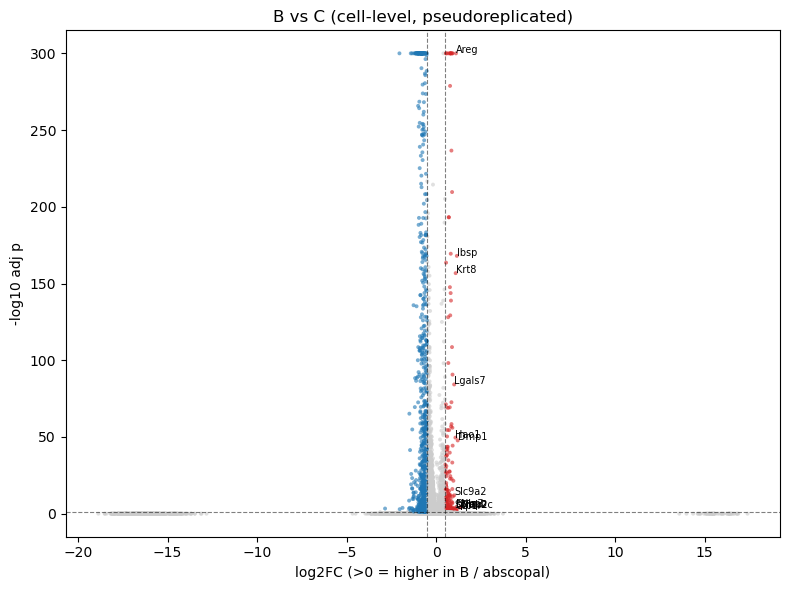

In [28]:
df = de_cell[CONTRASTS[0]].copy()
df["nlp"] = -np.log10(df["pvals_adj"].clip(lower=1e-300))
col = np.where((df.logfoldchanges > LFC) & (df.pvals_adj < PADJ), "#d62728",
      np.where((df.logfoldchanges < -LFC) & (df.pvals_adj < PADJ), "#1f77b4", "#cccccc"))
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df.logfoldchanges, df.nlp, c=col, s=8, alpha=0.6, linewidths=0, rasterized=True)
for v in (LFC, -LFC): ax.axvline(v, ls="--", lw=.8, c="k", alpha=.5)
ax.axhline(-np.log10(PADJ), ls="--", lw=.8, c="k", alpha=.5)
ax.set_xlabel("log2FC (>0 = higher in B / abscopal)"); ax.set_ylabel("-log10 adj p")
ax.set_title("B vs C (cell-level, pseudoreplicated)")
for _, r in df.query("pvals_adj<@PADJ and abs(logfoldchanges)>1").head(12).iterrows():
    ax.annotate(r["names"], (r.logfoldchanges, r.nlp), fontsize=7)
fig.tight_layout(); fig.savefig(OUT_DIR / "volcano_B_vs_C_cell.png", dpi=150, bbox_inches="tight"); plt.show()


## 5. Pseudobulk DESeq2 (pooled) — the honest unit

Sum counts per tissue → DESeq2 negative-binomial DE across tissues (n=4/2/4). Low power with 2 B
tissues; use direction + concordance, not raw padj.

In [29]:
pb_pool, grp_pool = pseudobulk_counts(adata, celltype=None, min_cells=1)
print("pseudobulk samples (tissues):"); print(grp_pool.to_string())

de_pb = {}
for test, ref in CONTRASTS:
    res = deseq2_de(pb_pool, grp_pool, test, ref)
    de_pb[(test, ref)] = res
    if res is not None:
        up = res.query("padj < @PADJ and log2FoldChange >  @PB_LFC")
        dn = res.query("padj < @PADJ and log2FoldChange < -@PB_LFC")
        print(f"{tag(test, ref)}: DESeq2 padj<{PADJ} up={len(up)}, down={len(dn)} "
              f"| direction |LFC|>{PB_LFC}: up={int((res.log2FoldChange>PB_LFC).sum())}, "
              f"down={int((res.log2FoldChange<-PB_LFC).sum())} (of {len(res)} genes)")
display(de_pb[CONTRASTS[0]].head(15))


pseudobulk samples (tissues):
RTCyPSCA_1_4        A_RT_primary
RTCyPSCA_2_4      B_RT_secondary
CyPSCA_2_4      C_noRT_secondary
RTCyPSCA_1_3        A_RT_primary
RTCyPSCA_2_3      B_RT_secondary
CyPSCA_2_3      C_noRT_secondary
CyPSCA_2_1      C_noRT_secondary
CyPSCA_2_2      C_noRT_secondary
RTCyPSCA_1_2        A_RT_primary
RTCyPSCA_1_5        A_RT_primary


/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_25021/2687488135.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(counts=c, metadata=meta, design="~group",


B_vs_C: DESeq2 padj<0.05 up=197, down=287 | direction |LFC|>0.5: up=1520, down=3216 (of 17196 genes)


/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_25021/2687488135.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(counts=c, metadata=meta, design="~group",


B_vs_A: DESeq2 padj<0.05 up=12, down=12 | direction |LFC|>0.5: up=1232, down=1471 (of 16351 genes)


,names,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
16741,Rhox5,6000.588525,0.790843,0.118661,6.664717,2.651758e-11,3.233023e-07
6666,Lgals7,2941.081710,1.057330,0.163280,6.475571,9.445411e-11,3.476858e-07
1246,Ptges,7408.036560,0.813976,0.135058,6.026885,1.671502e-09,2.911279e-06
2102,Hao1,1942.071069,1.160050,0.201054,5.769854,7.934017e-09,1.194671e-05
4638,Uchl1,2237.987766,0.919652,0.159884,5.752009,8.818930e-09,1.194671e-05
5352,Peg10,260.868661,1.027075,0.182175,5.637860,1.721762e-08,1.908339e-05
4968,Nos1,2191.885020,0.800344,0.145527,5.499640,3.805679e-08,3.314203e-05
12755,Ube2ql1,3040.153784,0.857016,0.157172,5.452714,4.960690e-08,3.780046e-05
4787,Prkg2,1061.474012,0.885688,0.174626,5.071911,3.938398e-07,2.527208e-04
13606,Ank,12865.363759,0.875312,0.175514,4.987128,6.128341e-07,3.557939e-04


## 6. Concordance + abscopal signature

Credible genes agree between cell-level ranking and DESeq2 **direction**. The abscopal signature is
up in B vs **both** A and C.

In [30]:
def cell_up(df):  return set(df.query("pvals_adj < @PADJ and logfoldchanges >  @LFC")["names"])
def pb_up(res):   return set(res.query("log2FoldChange > @PB_LFC")["names"]) if res is not None else set()

cu_bc, pu_bc = cell_up(de_cell[CONTRASTS[0]]), pb_up(de_pb[CONTRASTS[0]])
cu_ba, pu_ba = cell_up(de_cell[CONTRASTS[1]]), pb_up(de_pb[CONTRASTS[1]])

concordant_BC   = cu_bc & pu_bc                       # cell + DESeq2 agree (B vs C)
abscopal_sig    = cu_bc & cu_ba                       # up in B vs A AND C (cell-level)
abscopal_sig_pb = (cu_bc & pu_bc) & (cu_ba & pu_ba)   # + DESeq2-direction concordant

print(f"B-vs-C concordant (cell & DESeq2): {len(concordant_BC)}")
print(f"Abscopal signature (cell-level, up in B vs A AND C): {len(abscopal_sig)}")
print(f"  ...also DESeq2-direction concordant: {len(abscopal_sig_pb)}")
print("\nAbscopal-signature genes (DESeq2-concordant):")
print(sorted(abscopal_sig_pb)[:50])


B-vs-C concordant (cell & DESeq2): 193
Abscopal signature (cell-level, up in B vs A AND C): 4
  ...also DESeq2-direction concordant: 1

Abscopal-signature genes (DESeq2-concordant):
['Bok']


## 7. Per-cell-type DE (B vs C)

Which cell types drive the abscopal differences (cell-level Wilcoxon + DESeq2 where ≥2 tissues per
side have enough cells). Set `RUN_PER_CELLTYPE=False` in §2 to skip (it's the slow part).

In [31]:
test, ref = CONTRASTS[0]
de_ct_cell, de_ct_pb, ct_summary = {}, {}, []
if RUN_PER_CELLTYPE:
    cts = [c for c in adata.obs[CT_COL].astype(str).unique() if c != "Unknown"]
    for ct in sorted(cts):
        dfc = cell_level_de(adata, test, ref, celltype=ct)
        if dfc is None:
            continue
        de_ct_cell[ct] = dfc
        n_up = int(dfc.query("pvals_adj < @PADJ and logfoldchanges > @LFC").shape[0])
        n_dn = int(dfc.query("pvals_adj < @PADJ and logfoldchanges < -@LFC").shape[0])
        pb, g = pseudobulk_counts(adata, celltype=ct)
        dpb = deseq2_de(pb, g, test, ref) if pb is not None else None
        if dpb is not None:
            de_ct_pb[ct] = dpb
        ct_summary.append({"cell_type": ct,
                           "n_cells": int((adata.obs[CT_COL].astype(str) == ct).sum()),
                           "cell_up": n_up, "cell_down": n_dn,
                           "deseq2_testable": dpb is not None,
                           "deseq2_sig": int(dpb.query("padj < @PADJ").shape[0]) if dpb is not None else 0})
    ct_summary = pd.DataFrame(ct_summary).sort_values("cell_up", ascending=False)
    display(ct_summary)
else:
    ct_summary = pd.DataFrame()
    print("per-cell-type sweep skipped (RUN_PER_CELLTYPE=False)")


/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_25021/2687488135.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(counts=c, metadata=meta, design="~group",
/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_25021/2687488135.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(counts=c, metadata=meta, design="~group",
/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_25021/2687488135.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a f

,cell_type,n_cells,cell_up,cell_down,deseq2_testable,deseq2_sig
4,Classical_Mono,30355,373,693,True,116
12,N2_like_Neu,5054,276,113,True,114
11,N1_like_Neu,35052,104,774,True,276
6,Erythrocyte,18158,72,595,True,73
3,Cancer_cell,4785,49,415,False,0
10,M2_like_Mac,4302,32,39,True,0
7,Fibroblast,713,18,41,False,0
2,CD8_T,4260,14,2563,True,1
5,Endothelial,1008,13,95,False,0
13,NK,1716,10,676,False,0


## 8. Enrichment — Enrichr (gseapy), offline ORA fallback

Run on the cell-level up/down lists for B vs C (mirrors RegionComparison). For a stricter input,
swap in `concordant_BC` or `abscopal_sig_pb`.

In [42]:
background = adata.var_names.astype(str).tolist()
df = de_cell[CONTRASTS[0]]
up_genes   = df.query("pvals_adj < @PADJ and logfoldchanges >  @LFC").head(N_ENRICH)["names"].tolist()
down_genes = df.query("pvals_adj < @PADJ and logfoldchanges < -@LFC").head(N_ENRICH)["names"].tolist()
print(f"enrichment input: up={len(up_genes)}, down={len(down_genes)} genes")

enr_up   = run_enrichment(up_genes,   background)
enr_down = run_enrichment(down_genes, background)
print("\nTop pathways UP in B (abscopal) vs C:")
display(enr_up.head(40))
print("Top pathways DOWN in B vs C:")
display(enr_down.head(40))


enrichment input: up=197, down=300 genes

Top pathways UP in B (abscopal) vs C:


,gene_set,term,overlap,pval,padj,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,genes
0,MSigDB_Hallmark_2020,KRAS Signaling Up,15/200,1.386714e-09,5.269514e-08,0,0,8.739828,178.260400,MMD;ETV1;NGF;MMP10;EREG;ANO1;GPRC5B;BMP2;PLAU;...
1,MSigDB_Hallmark_2020,Estrogen Response Early,11/200,4.923114e-06,6.235944e-05,0,0,6.137395,75.008604,GJA1;TFAP2C;KRT18;TGIF2;IGFBP4;FASN;KRT8;SLC2A...
2,MSigDB_Hallmark_2020,Glycolysis,11/200,4.923114e-06,6.235944e-05,0,0,6.137395,75.008604,NT5E;EGLN3;TPI1;STC1;PLOD2;AK4;MIF;ANGPTL4;FKB...
3,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,9/199,1.634108e-04,1.074624e-03,0,0,4.941685,43.087755,NT5E;BMP2;NCS1;ODC1;SPRY4;SPP1;SH3BGRL2;ITGA6;...
4,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,9/200,1.696775e-04,1.074624e-03,0,0,4.915562,42.674996,CDH6;GJA1;TAGLN;NT5E;IGFBP4;SPP1;PLOD2;AREG;PTHLH
5,MSigDB_Hallmark_2020,p53 Pathway,9/200,1.696775e-04,1.074624e-03,0,0,4.915562,42.674996,CDKN2B;BMP2;PMM1;TRAF4;MDM2;NUPR1;HRAS;TM4SF1;...
6,GO_Biological_Process_2023,Regulation Of Apoptotic Process (GO:0042981),21/705,6.734803e-06,2.688768e-03,0,0,3.335153,39.715737,TFAP2A;EGLN3;RTKN;GSTP1;NME2;HMGA2;TNFRSF10B;C...
7,GO_Biological_Process_2023,Regulation Of Cell Population Proliferation (G...,22/766,7.146226e-06,2.688768e-03,0,0,3.220415,38.158456,TFAP2A;WWTR1;COL18A1;CDKN2B;EGLN3;TFAP2C;ITGA1...
8,GO_Biological_Process_2023,Regulation Of Epithelial Cell Proliferation (G...,8/91,3.247277e-06,2.688768e-03,0,0,10.056735,127.093936,SOX2;CDKN2B;SIX4;NME2;NUPR1;HRAS;EREG;FGF10
9,GO_Biological_Process_2023,Positive Regulation Of Cell Population Prolife...,17/483,6.301400e-06,2.688768e-03,0,0,3.919039,46.929470,WWTR1;NME2;HMGA2;EMP2;AREG;PTHLH;EREG;FOSL1;GJ...


Top pathways DOWN in B vs C:


,gene_set,term,overlap,pval,padj,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,genes
0,Reactome_2022,Immune System R-HSA-168256,58/1943,2.589992e-07,0.000178,0,0,2.265099,34.353483,TINAGL1;CGAS;IL27;SLC2A3;TNFSF13B;GRAP2;TBC1D1...
1,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,18/320,1.800542e-06,0.002888,0,0,4.099901,54.231130,PTGER4;TRAF3IP3;TXK;CGAS;IL16;TYK2;NOD2;POU2F2...
2,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),15/236,3.013001e-06,0.002888,0,0,4.638962,58.973143,PTGER4;CD96;PARP4;HP;MEFV;CXCL5;PIK3CG;NFATC4;...
3,Reactome_2022,Cytokine Signaling In Immune System R-HSA-1280215,26/702,2.290496e-05,0.005245,0,0,2.670410,28.531078,RNASEL;IL27;TNFRSF11B;NOD2;TNFSF13B;SOCS2;IL1R...
4,Reactome_2022,Signaling By Interleukins R-HSA-449147,20/453,1.833999e-05,0.005245,0,0,3.178324,34.664158,MEF2C;IL27;IL16;LIFR;IRAK3;TYK2;NOD2;OSMR;BATF...
5,KEGG_2019_Mouse,Cytokine-cytokine receptor interaction,15/292,3.790978e-05,0.007506,0,0,3.690481,37.570207,IL27;IL16;LIFR;TNFRSF11B;OSMR;CXCL5;TNFSF13B;I...
6,Reactome_2022,GPCR Downstream Signaling R-HSA-388396,23/619,6.536126e-05,0.011226,0,0,2.661498,25.645077,PTGER4;P2RY13;RAMP2;ARHGEF37;ARHGEF10L;PIK3CG;...
7,Reactome_2022,Innate Immune System R-HSA-168249,32/1035,8.903859e-05,0.011590,0,0,2.225800,20.758794,TINAGL1;CFH;TXK;HVCN1;CGAS;SLC2A3;NOD2;MEFV;PL...
8,Reactome_2022,MyD88 Deficiency (TLR2/4) R-HSA-5602498,4/17,1.012192e-04,0.011590,0,0,20.464657,188.238453,BTK;TLR6;S100A9;S100A8
9,GO_Biological_Process_2023,Pattern Recognition Receptor Signaling Pathway...,7/56,1.969057e-05,0.012582,0,0,9.581180,103.815635,CGAS;TLR8;NLRP3;TLR6;NOD2;ALPK1;MEFV


In [43]:
background = adata.var_names.astype(str).tolist()
df = de_cell[CONTRASTS[1]]
up_genes   = df.query("pvals_adj < @PADJ and logfoldchanges >  @LFC").head(N_ENRICH)["names"].tolist()
down_genes = df.query("pvals_adj < @PADJ and logfoldchanges < -@LFC").head(N_ENRICH)["names"].tolist()
print(f"enrichment input: up={len(up_genes)}, down={len(down_genes)} genes")

enr_up   = run_enrichment(up_genes,   background)
enr_down = run_enrichment(down_genes, background)
print("\nTop pathways UP in B (abscopal) vs A:")
display(enr_up.head(40))
print("Top pathways DOWN in B vs A:")
display(enr_down.head(40))


enrichment input: up=70, down=120 genes

Top pathways UP in B (abscopal) vs A:


,gene_set,term,overlap,pval,padj,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,genes
0,MSigDB_Hallmark_2020,E2F Targets,16/200,8.413309e-18,2.019194e-16,0,0,31.797101,1250.157633,TOP2A;CDCA3;SHMT1;PLK1;HMMR;MKI67;CDC20;CCNB2;...
1,MSigDB_Hallmark_2020,G2-M Checkpoint,15/200,2.619670e-16,3.143604e-15,0,0,29.108108,1044.349818,TOP2A;UBE2C;PLK1;KIF11;HMMR;MKI67;CENPA;CDC20;...
2,Reactome_2022,"Cell Cycle, Mitotic R-HSA-69278",16/523,2.568662e-11,8.887571e-09,0,0,11.351012,276.794998,TOP2A;NUP210;UBE2C;PLK1;HMMR;CENPA;CDC20;CCNA2...
3,Reactome_2022,Cell Cycle R-HSA-1640170,16/654,6.842721e-10,1.183791e-07,0,0,8.959480,189.068906,TOP2A;NUP210;UBE2C;PLK1;HMMR;CENPA;CDC20;CCNA2...
4,GO_Biological_Process_2023,Mitotic Cytokinesis (GO:0000281),7/59,1.396107e-09,7.511055e-07,0,0,42.474359,866.034269,ANLN;RACGAP1;STMN1;PLK1;BIRC5;KIF20A;CENPA
5,GO_Biological_Process_2023,Cytoskeleton-Dependent Cytokinesis (GO:0061640),7/81,1.339195e-08,3.602436e-06,0,0,29.813814,540.483056,ANLN;RACGAP1;STMN1;PLK1;BIRC5;KIF20A;CENPA
6,MSigDB_Hallmark_2020,Mitotic Spindle,8/199,4.645848e-07,3.716679e-06,0,0,13.334910,194.451275,TOP2A;CCNB2;ANLN;RACGAP1;PLK1;CDK1;BIRC5;KIF11
7,Reactome_2022,M Phase R-HSA-68886,11/380,7.997000e-08,7.577440e-06,0,0,9.883377,161.510335,CDC20;CCNB2;NUP210;UBE2C;PLK1;CDK1;BIRC5;NCAPD...
8,Reactome_2022,Resolution Of Sister Chromatid Cohesion R-HSA-...,7/106,8.760046e-08,7.577440e-06,0,0,22.257015,361.687161,CDC20;CCNB2;PLK1;CDK1;BIRC5;CENPA;NUP37
9,GO_Biological_Process_2023,Microtubule Cytoskeleton Organization Involved...,6/59,5.749446e-08,1.031067e-05,0,0,35.159788,586.169116,STMN1;PLK1;CDK1;TACC3;BIRC5;KIF11


Top pathways DOWN in B vs A:


,gene_set,term,overlap,pval,padj,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,genes
0,MSigDB_Hallmark_2020,Interferon Gamma Response,21/200,2.036659e-20,5.702644e-19,0,0,23.346369,1058.533494,CD86;IL15RA;CD274;RSAD2;GCH1;IL15;GZMA;DDX60;P...
1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,14/200,1.673366e-11,2.342712e-10,0,0,13.984378,347.002751,IL15RA;GCH1;PTGS2;TNF;SLC2A6;IFIT2;IFIH1;CXCL1...
2,MSigDB_Hallmark_2020,Inflammatory Response,13/200,2.320244e-10,1.624171e-09,0,0,12.794692,283.839742,IL15RA;GCH1;IL15;CXCL10;CCL7;IL1B;CCRL2;NLRP3;...
3,MSigDB_Hallmark_2020,Allograft Rejection,13/200,2.320244e-10,1.624171e-09,0,0,12.794692,283.839742,CD86;CCR1;CCL11;NOS2;IL15;GZMA;TNF;IFNG;CCL7;I...
4,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),15/236,1.209640e-11,1.370522e-08,0,0,12.707822,319.450657,CCR1;CCL11;NOS2;FPR2;TNF;CXCL10;CCL8;IFNG;CCL7...
5,MSigDB_Hallmark_2020,Myogenesis,12/200,2.946719e-09,1.375135e-08,0,0,11.638298,228.606122,MYLPF;MYH1;ACTA1;CSRP3;MYH2;DES;MB;TNNC2;TNNT3...
6,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,9/87,2.576118e-09,1.375135e-08,0,0,20.584200,407.093347,CCR1;IL15RA;CXCL10;CCL7;IL1R2;IL1B;PIM1;TNF;TLR2
7,MSigDB_Hallmark_2020,Interferon Alpha Response,9/97,6.827449e-09,2.730980e-08,0,0,18.235872,342.876609,IFIH1;CXCL10;RSAD2;IL15;CCRL2;DDX60;PARP14;GBP...
8,Reactome_2022,Immune System R-HSA-168256,37/1943,9.516431e-11,2.864446e-08,0,0,4.203833,97.005200,CD86;CD274;CCL11;FPR2;PTGS2;SAMHD1;TNF;IFIT2;C...
9,Reactome_2022,Interleukin-10 Signaling R-HSA-6783783,8/45,2.374445e-10,3.573540e-08,0,0,38.306950,848.923652,CD86;CCR1;CXCL10;IL1R2;IL1B;CCL2;PTGS2;TNF


### 8c. Offline ORA over the LOCAL GMTs (Hallmark + Reactome + GO-BP, mouse v2026.1)

Hypergeometric ORA against your local MSigDB files via `_ora` — this is where local-GMT terms like
`GOBP_CELL_KILLING` (granzymes) live; the online Enrichr libraries in §8/§11 don't carry them. Run
for **both** contrasts (B vs C and B vs A), up and down.

In [51]:
CONTRASTS

[('B_RT_secondary', 'C_noRT_secondary'), ('B_RT_secondary', 'A_RT_primary')]

In [ ]:
set(B_vs_C["gene_set"]) & set(B_vs_A["gene_set"])

In [44]:
background = adata.var_names.astype(str).tolist()
ora_results = {}
for test, ref in CONTRASTS:
    d = de_cell[(test, ref)]
    up   = d.query("pvals_adj < @PADJ and logfoldchanges >  @LFC").head(N_ENRICH)["names"].tolist()
    down = d.query("pvals_adj < @PADJ and logfoldchanges < -@LFC").head(N_ENRICH)["names"].tolist()
    eu = _ora(up,   all_gene_sets, background)
    ed = _ora(down, all_gene_sets, background)
    ora_results[(test, ref)] = (eu, ed)
    eu.to_csv(OUT_DIR / f"ora_local_{tag(test, ref)}_UP.csv", index=False)
    ed.to_csv(OUT_DIR / f"ora_local_{tag(test, ref)}_DOWN.csv", index=False)
    print(f"\n################ {tag(test, ref)}  (offline ORA, local GMTs)  up={len(up)} down={len(down)} ################")
    print(f"--- UP in B vs {short[ref]} ---");   display(eu.head(40))
    print(f"--- DOWN in B vs {short[ref]} ---"); display(ed.head(40))

# Focused view: cytotoxicity / cell-killing terms enriched UP in B (the result you remembered)
print("\n################ Cytotoxic / cell-killing terms UP in B ################")
pat = "KILL|CYTOTOX|GRANZYME|PERFORIN|NATURAL_KILLER|APOPTO|_DEATH"
for test, ref in CONTRASTS:
    eu = ora_results[(test, ref)][0]
    hit = eu[eu["gene_set"].str.contains(pat, case=False, regex=True) & (eu["padj"] < 0.05)]
    print(f"\n{tag(test, ref)} — cytotoxic terms (padj<0.05): {len(hit)}")
    display(hit[["gene_set", "overlap", "padj", "genes"]].head(15))



################ B_vs_C  (offline ORA, local GMTs)  up=197 down=300 ################
--- UP in B vs C ---


,gene_set,term,set_size,overlap,pval,genes,padj
0,HALLMARK_KRAS_SIGNALING_UP,HALLMARK_KRAS_SIGNALING_UP,196,16,2.185873e-10,"Angptl4,Ank,Ano1,Bmp2,Cpe,Ereg,Etv1,Gprc5b,Kif...",3.235092e-07
1,GOBP_SEX_DIFFERENTIATION,GOBP_SEX_DIFFERENTIATION,333,18,1.204289e-08,"Bok,Ctsl,Ereg,Fgf10,Fkbp4,Gja1,Gpr149,Hmga2,Ho...",8.911739e-06
2,GOBP_REPRODUCTIVE_SYSTEM_DEVELOPMENT,GOBP_REPRODUCTIVE_SYSTEM_DEVELOPMENT,375,18,7.380968e-08,"Bok,Ctsl,Ereg,Fgf10,Fkbp4,Gja1,Gpr149,Hmga2,Ho...",3.641278e-05
3,GOBP_MALE_SEX_DIFFERENTIATION,GOBP_MALE_SEX_DIFFERENTIATION,196,13,1.333966e-07,"Bok,Ctsl,Fgf10,Fkbp4,Gja1,Hmga2,Hoxa11,Nupr1,S...",4.935675e-05
4,GOBP_NEGATIVE_REGULATION_OF_NEURON_APOPTOTIC_P...,GOBP_NEGATIVE_REGULATION_OF_NEURON_APOPTOTIC_P...,218,13,4.548737e-07,"Bok,Clu,Cpe,Glp1r,Hras,Map3k12,Nefl,Ngf,Nos1,S...",1.346426e-04
5,GOBP_DEVELOPMENT_OF_PRIMARY_SEXUAL_CHARACTERIS...,GOBP_DEVELOPMENT_OF_PRIMARY_SEXUAL_CHARACTERIS...,285,14,1.672953e-06,"Bok,Ctsl,Ereg,Gja1,Gpr149,Hmga2,Hoxa11,Nupr1,P...",4.126618e-04
6,GOBP_NEURON_APOPTOTIC_PROCESS,GOBP_NEURON_APOPTOTIC_PROCESS,376,16,1.968966e-06,"Bok,Clu,Cpe,Egln3,Glp1r,Hras,Itga1,Map3k12,Nef...",4.162957e-04
7,GOBP_MORPHOGENESIS_OF_A_BRANCHING_STRUCTURE,GOBP_MORPHOGENESIS_OF_A_BRANCHING_STRUCTURE,254,13,2.528654e-06,"Areg,Bmp2,Cpe,Ctsl,Fgf10,Foxf1,Hhip,Hmga2,Hoxa...",4.678011e-04
8,GOBP_BIOMINERAL_TISSUE_DEVELOPMENT,GOBP_BIOMINERAL_TISSUE_DEVELOPMENT,188,11,4.275387e-06,"Ank,Bmp2,Dmp1,Gja1,Hacd1,Ibsp,Odaph,Pthlh,Spp1...",5.855454e-04
9,GOBP_EPITHELIAL_TUBE_BRANCHING_INVOLVED_IN_LUN...,GOBP_EPITHELIAL_TUBE_BRANCHING_INVOLVED_IN_LUN...,41,6,3.759741e-06,"Ctsl,Fgf10,Foxf1,Hhip,Hmga2,Sox2",5.855454e-04


--- DOWN in B vs C ---


,gene_set,term,set_size,overlap,pval,genes,padj
0,GOBP_LYMPHOCYTE_DIFFERENTIATION,GOBP_LYMPHOCYTE_DIFFERENTIATION,450,33,2.050457e-13,"Atp11c,Batf,Btk,Cd4,Clec4d,Dusp10,Eomes,Fas,Gi...",3.824101e-10
1,GOBP_REGULATION_OF_IMMUNE_EFFECTOR_PROCESS,GOBP_REGULATION_OF_IMMUNE_EFFECTOR_PROCESS,436,31,2.585704e-12,"Arid5a,Btk,Cd22,Cd96,Cfh,Cgas,Cxcl5,Dusp10,Gim...",2.411169e-09
2,GOBP_T_CELL_DIFFERENTIATION,GOBP_T_CELL_DIFFERENTIATION,336,27,4.302805e-12,"Batf,Cd4,Clec4d,Dusp10,Eomes,Fas,Gimap1,Gimap3...",2.674911e-09
3,GOBP_POSITIVE_REGULATION_OF_CELL_ACTIVATION,GOBP_POSITIVE_REGULATION_OF_CELL_ACTIVATION,385,28,1.842733e-11,"Atp11c,Btk,Cd4,Clec4d,Dusp10,Efnb2,Fcho1,Gimap...",8.591743e-09
4,GOBP_LEUKOCYTE_CELL_CELL_ADHESION,GOBP_LEUKOCYTE_CELL_CELL_ADHESION,423,27,7.943821e-10,"Alox5,Cd4,Cfh,Cxcl12,Dusp10,Efnb2,Fcho1,Gimap3...",2.963045e-07
5,GOBP_ALPHA_BETA_T_CELL_ACTIVATION,GOBP_ALPHA_BETA_T_CELL_ACTIVATION,215,18,9.419790e-09,"Batf,Eomes,Gimap3,Gpr18,Il12rb2,Il27,Myb,Nfkbi...",2.509701e-06
6,GOBP_ADAPTIVE_IMMUNE_RESPONSE_BASED_ON_SOMATIC...,GOBP_ADAPTIVE_IMMUNE_RESPONSE_BASED_ON_SOMATIC...,351,23,9.190329e-09,"Arid5a,Batf,Btk,Cd4,Cfh,Fas,Gimap3,H2-Q4,Icosl...",2.509701e-06
7,GOBP_POSITIVE_REGULATION_OF_LYMPHOCYTE_ACTIVATION,GOBP_POSITIVE_REGULATION_OF_LYMPHOCYTE_ACTIVATION,326,22,1.146996e-08,"Atp11c,Btk,Cd4,Dusp10,Efnb2,Fcho1,Gimap3,Icosl...",2.673934e-06
8,GOBP_POSITIVE_REGULATION_OF_LEUKOCYTE_CELL_CEL...,GOBP_POSITIVE_REGULATION_OF_LEUKOCYTE_CELL_CEL...,272,20,1.292669e-08,"Alox5,Cd4,Dusp10,Efnb2,Fcho1,Gimap3,Icosl,Igf1...",2.678697e-06
9,GOBP_ALPHA_BETA_T_CELL_DIFFERENTIATION,GOBP_ALPHA_BETA_T_CELL_DIFFERENTIATION,150,15,1.534510e-08,"Batf,Eomes,Gimap3,Gpr18,Il12rb2,Il27,Myb,Nfkbi...",2.861861e-06



################ B_vs_A  (offline ORA, local GMTs)  up=70 down=120 ################
--- UP in B vs A ---


...

,gene_set,term,set_size,overlap,pval,genes,padj
0,HALLMARK_INTERFERON_GAMMA_RESPONSE,HALLMARK_INTERFERON_GAMMA_RESPONSE,180,21,5.736782e-21,"Ccl7,Cd274,Cd69,Cd86,Cfb,Cxcl10,Ddx60,Gch1,Gzm...",6.385038e-18
1,GOBP_DEFENSE_RESPONSE_TO_VIRUS,GOBP_DEFENSE_RESPONSE_TO_VIRUS,324,20,1.434189e-14,"Acod1,Cd86,Cxcl10,Ddx60,Gbp4,Gbp5,Ifih1,Ifit1b...",7.981261e-12
2,GOBP_ACTIVATION_OF_INNATE_IMMUNE_RESPONSE,GOBP_ACTIVATION_OF_INNATE_IMMUNE_RESPONSE,349,19,6.554617e-13,"Acod1,Cd274,Cd86,Clec4e,Ddx60,Gbp5,Ifi204,Ifi2...",2.431763e-10
3,GOBP_RESPONSE_TO_VIRUS,GOBP_RESPONSE_TO_VIRUS,407,20,1.019381e-12,"Acod1,Cd86,Cxcl10,Ddx60,Gbp4,Gbp5,Ifih1,Ifit1b...",2.836426e-10
4,GOBP_POSITIVE_REGULATION_OF_RESPONSE_TO_BIOTIC...,GOBP_POSITIVE_REGULATION_OF_RESPONSE_TO_BIOTIC...,451,20,6.653726e-12,"Acod1,Cd274,Cd86,Clec4e,Ddx60,Fpr2,Gbp5,Ifi204...",1.236016e-09
5,GOBP_CELLULAR_RESPONSE_TO_BIOTIC_STIMULUS,GOBP_CELLULAR_RESPONSE_TO_BIOTIC_STIMULUS,257,16,6.663158e-12,"Acod1,Ankrd1,Ccl2,Cd274,Cd86,Cxcl10,Gbp5,Gch1,...",1.236016e-09
6,GOBP_RESPONSE_TO_MOLECULE_OF_BACTERIAL_ORIGIN,GOBP_RESPONSE_TO_MOLECULE_OF_BACTERIAL_ORIGIN,360,18,1.157192e-11,"Acod1,Ankrd1,Ccl2,Cd274,Cd86,Cxcl10,Gbp5,Gch1,...",1.839936e-09
7,GOBP_RESPONSE_TO_TYPE_II_INTERFERON,GOBP_RESPONSE_TO_TYPE_II_INTERFERON,137,12,6.359148e-11,"Acod1,Ccl2,Gbp4,Gbp5,Gbp9,Gch1,Ifng,Nos2,Parp1...",8.039188e-09
8,GOBP_CELLULAR_RESPONSE_TO_TYPE_II_INTERFERON,GOBP_CELLULAR_RESPONSE_TO_TYPE_II_INTERFERON,106,11,6.500691e-11,"Acod1,Ccl2,Gbp4,Gbp5,Gbp9,Ifng,Nos2,Parp14,Pim...",8.039188e-09
9,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_TNFA_SIGNALING_VIA_NFKB,194,13,2.843999e-10,"Ccrl2,Cd69,Cxcl10,Gch1,Ifih1,Ifit2,Il15ra,Il1b...",3.165371e-08



################ Cytotoxic / cell-killing terms UP in B ################

B_vs_C — cytotoxic terms (padj<0.05): 10


,gene_set,overlap,padj,genes
4,GOBP_NEGATIVE_REGULATION_OF_NEURON_APOPTOTIC_P...,13,0.000135,"Bok,Clu,Cpe,Glp1r,Hras,Map3k12,Nefl,Ngf,Nos1,S..."
6,GOBP_NEURON_APOPTOTIC_PROCESS,16,0.000416,"Bok,Clu,Cpe,Egln3,Glp1r,Hras,Itga1,Map3k12,Nef..."
44,GOBP_NEGATIVE_REGULATION_OF_APOPTOTIC_SIGNALIN...,10,0.008225,"Bok,Clu,Cpe,Fgf10,Gstp1,Ier3,Itga6,Mdm2,Mif,Unc5b"
96,GOBP_EXTRINSIC_APOPTOTIC_SIGNALING_PATHWAY,9,0.016645,"Bok,Fgf10,Gstp1,Itga6,Krt18,Krt8,Ngf,Tnfrsf10b..."
114,GOBP_EPITHELIAL_CELL_APOPTOTIC_PROCESS,5,0.021966,"Bok,Krt18,Krt8,Ngf,Nupr1"
183,GOBP_REGULATION_OF_APOPTOTIC_SIGNALING_PATHWAY,11,0.037612,"Bok,Clu,Cpe,Fgf10,Gstp1,Ier3,Itga6,Mdm2,Mif,Nu..."
194,GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY_IN_...,5,0.040689,"Bok,Clu,Ier3,Mif,Nupr1"
208,HALLMARK_APOPTOSIS,6,0.042496,"Ank,Bmp2,Clu,Ereg,Ier3,Krt18"
210,GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY,9,0.042496,"Bok,Clu,Cpe,Hras,Ier3,Mdm2,Mif,Nupr1,Tnfrsf10b"
239,GOBP_NEGATIVE_REGULATION_OF_MITOCHONDRIAL_OUTE...,2,0.046660,"Bok,Ier3"



B_vs_A — cytotoxic terms (padj<0.05): 15


,gene_set,overlap,padj,genes
8,GOBP_CELL_KILLING,11,1.427732e-07,"Ctsg,Cxcl14,Gzmc,Gzmd,Gzme,Gzmf,Gzmg,Klrc1,Klr..."
50,GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY,6,3.150382e-04,"Ctsg,Gzmc,Klrc1,Klrd1,Klre1,Prf1"
74,GOBP_POSITIVE_REGULATION_OF_CELL_KILLING,4,1.853604e-03,"Klrc1,Klrd1,Klre1,Prf1"
86,GOBP_POSITIVE_REGULATION_OF_NATURAL_KILLER_CEL...,3,2.491543e-03,"Klrc1,Klrd1,Klre1"
88,GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY,4,2.491543e-03,"Gzmc,Klrc1,Klrd1,Klre1"
91,GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_S...,2,2.973397e-03,"Gzmc,Prf1"
113,GOBP_PYROPTOTIC_CELL_DEATH,2,4.858842e-03,"Gzmc,Prf1"
126,GOBP_REGULATION_OF_CELL_KILLING,4,5.859048e-03,"Klrc1,Klrd1,Klre1,Prf1"
140,GOBP_REGULATION_OF_NATURAL_KILLER_CELL_MEDIATE...,3,8.201593e-03,"Klrc1,Klrd1,Klre1"
168,GOBP_NEGATIVE_REGULATION_OF_NATURAL_KILLER_CEL...,2,1.672296e-02,"Klrd1,Klre1"


### 8d. Enrichment bar-plots of the offline-ORA terms (per contrast)

Bar plots (-log10 adj p) of the local-GMT ORA from §8c, one figure per contrast. Defaults to the
**cytotoxicity / cell-killing** terms (`TERM_FILTER`) and plots **all** of them (set
`TERM_FILTER = None` to plot every significant pathway; flip `DIRECTION` for down-in-B).

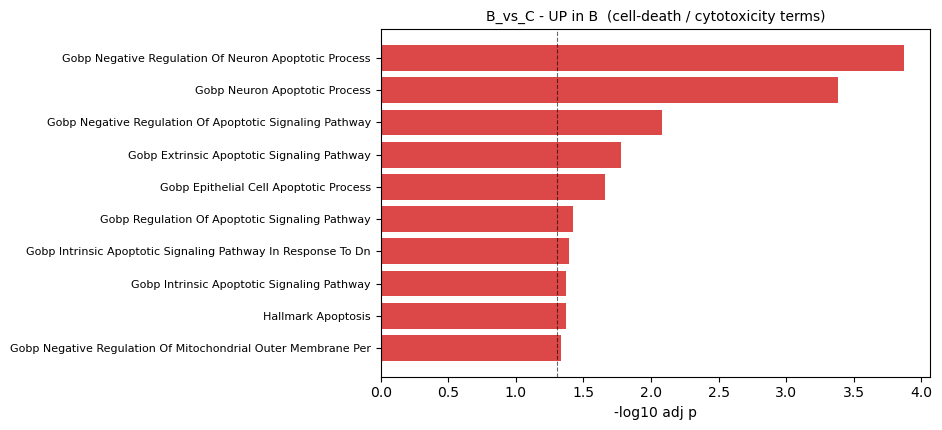

B_vs_C UP: 10 terms plotted


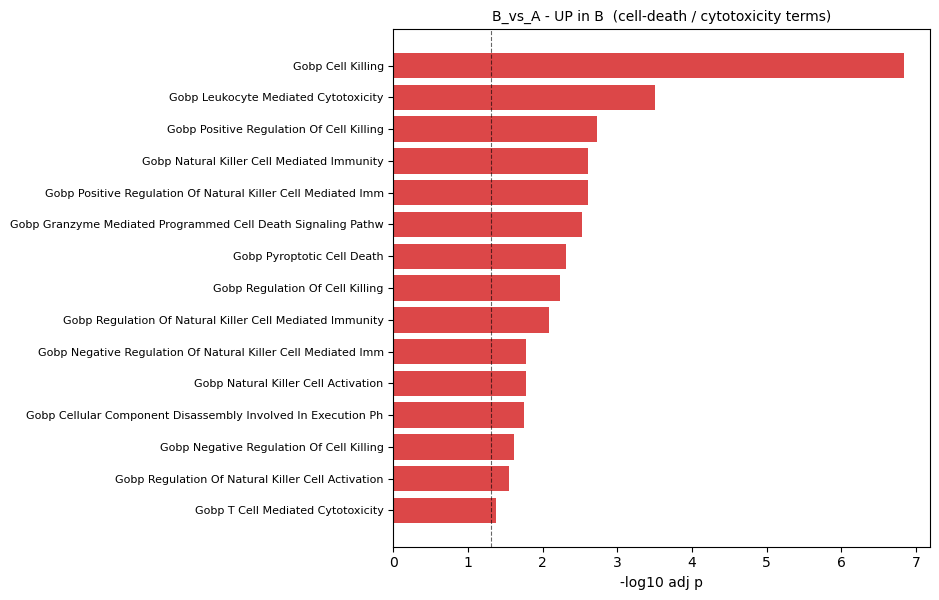

B_vs_A UP: 15 terms plotted


In [53]:
# pathway-enrichment figures from the §8c offline ORA (ora_results)
TERM_FILTER = "KILL|CYTOTOX|GRANZYME|PERFORIN|NATURAL_KILLER|APOPTO|_DEATH"  # same terms as the §8c table; set None to plot ALL significant
DIRECTION   = "UP"            # "UP" = higher in B, "DOWN" = lower in B
PADJ_CUT    = 0.05

def plot_ora_terms(ax, enr, title, color, term_filter=None, padj_cut=PADJ_CUT):
    d = enr.copy()
    if term_filter:
        d = d[d["gene_set"].str.contains(term_filter, case=False, regex=True)]
    d = d[d["padj"] < padj_cut].copy()
    if d.empty:
        ax.text(.5, .5, "no significant terms", ha="center", va="center",
                transform=ax.transAxes, color="gray"); ax.set_title(title, fontsize=10); ax.axis("off")
        return 0
    d["nlp"] = -np.log10(d["padj"].clip(lower=1e-300))
    d["lab"] = d["gene_set"].str.replace("_", " ").str.title().str[:60]
    d = d.sort_values("nlp")
    ax.barh(d["lab"], d["nlp"], color=color, alpha=.85)
    ax.axvline(-np.log10(0.05), ls="--", lw=.8, c="k", alpha=.6)
    ax.set_xlabel("-log10 adj p"); ax.set_title(title, fontsize=10); ax.tick_params(axis="y", labelsize=8)
    return len(d)

color = "#d62728" if DIRECTION == "UP" else "#1f77b4"
suffix = "cytotox" if TERM_FILTER else "allsig"
for test, ref in CONTRASTS:
    enr = ora_results[(test, ref)][0 if DIRECTION == "UP" else 1]
    d = enr if not TERM_FILTER else enr[enr["gene_set"].str.contains(TERM_FILTER, case=False, regex=True)]
    n = int((d["padj"] < PADJ_CUT).sum())
    fig, ax = plt.subplots(figsize=(9.5, max(2.0, 0.34 * max(n, 1) + 1.0)))
    ttl = f"{tag(test, ref)} - {DIRECTION} in B" + ("  (cell-death / cytotoxicity terms)" if TERM_FILTER else "  (all significant)")
    n = plot_ora_terms(ax, enr, ttl, color, TERM_FILTER)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"ora_local_{tag(test, ref)}_{DIRECTION}_{suffix}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{tag(test, ref)} {DIRECTION}: {n} terms plotted")


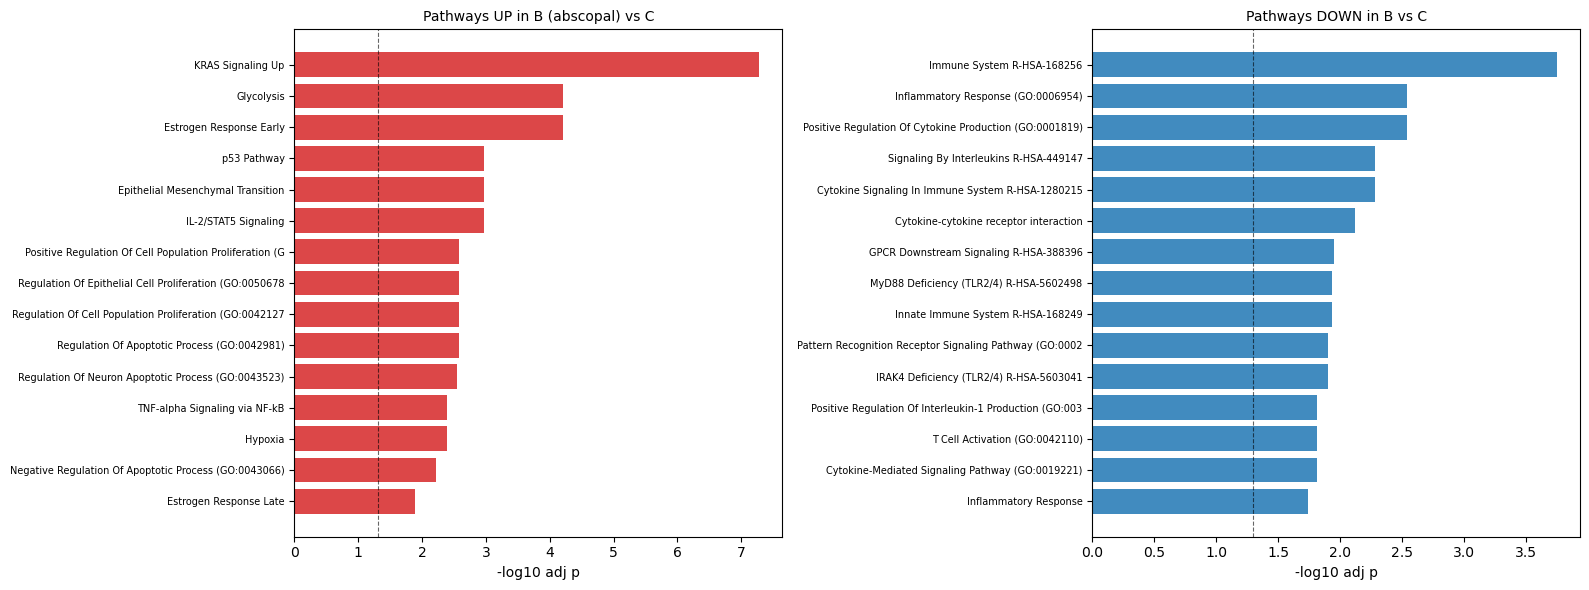

In [33]:
def enr_bar(ax, enr, title, color):
    d = enr[enr["padj"] < 0.05].head(15).copy() if "padj" in enr and len(enr) else enr.head(0)
    if d.empty:
        ax.text(.5, .5, "no significant terms", ha="center", va="center", transform=ax.transAxes); ax.axis("off"); return
    d["nlp"] = -np.log10(d["padj"].clip(lower=1e-300))
    d["lab"] = d["term"].astype(str).str.replace("_", " ").str[:55]
    d = d.sort_values("nlp")
    ax.barh(d["lab"], d["nlp"], color=color, alpha=.85)
    ax.axvline(-np.log10(0.05), ls="--", lw=.8, c="k", alpha=.6)
    ax.set_xlabel("-log10 adj p"); ax.set_title(title, fontsize=10); ax.tick_params(axis="y", labelsize=7)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
enr_bar(axes[0], enr_up,   "Pathways UP in B (abscopal) vs C",  "#d62728")
enr_bar(axes[1], enr_down, "Pathways DOWN in B vs C",           "#1f77b4")
fig.tight_layout(); fig.savefig(OUT_DIR / "enrichment_B_vs_C.png", dpi=150, bbox_inches="tight"); plt.show()


## 9. Save results

In [34]:
for (test, ref), df in de_cell.items():
    df.to_csv(OUT_DIR / f"DE_cell_{tag(test, ref)}.csv", index=False)
for (test, ref), res in de_pb.items():
    if res is not None:
        res.to_csv(OUT_DIR / f"DE_deseq2_{tag(test, ref)}.csv", index=False)
for ct, df in de_ct_cell.items():
    df.to_csv(OUT_DIR / f"DE_cell_B_vs_C__{ct}.csv", index=False)
for ct, res in de_ct_pb.items():
    res.to_csv(OUT_DIR / f"DE_deseq2_B_vs_C__{ct}.csv", index=False)
if len(ct_summary):
    ct_summary.to_csv(OUT_DIR / "per_celltype_DE_summary.csv", index=False)
enr_up.to_csv(OUT_DIR / "enrichment_B_vs_C_UP.csv", index=False)
enr_down.to_csv(OUT_DIR / "enrichment_B_vs_C_DOWN.csv", index=False)
pd.Series(sorted(abscopal_sig_pb), name="gene").to_csv(OUT_DIR / "abscopal_signature_genes.csv", index=False)
print("Saved to:", OUT_DIR)
for f in sorted(OUT_DIR.iterdir()):
    print("  ", f.name)


Saved to: /Users/janzules/Roselab/Spatial/CAR_T/data/ifng_hotspot_featureset/group_de_enrichment
   DE_cell_B_vs_A.csv
   DE_cell_B_vs_C.csv
   DE_cell_B_vs_C__B.csv
   DE_cell_B_vs_C__CD4_T.csv
   DE_cell_B_vs_C__CD8_T.csv
   DE_cell_B_vs_C__Cancer_cell.csv
   DE_cell_B_vs_C__Classical_Mono.csv
   DE_cell_B_vs_C__Endothelial.csv
   DE_cell_B_vs_C__Erythrocyte.csv
   DE_cell_B_vs_C__Fibroblast.csv
   DE_cell_B_vs_C__Intermediate_Mac.csv
   DE_cell_B_vs_C__M1_like_Mac.csv
   DE_cell_B_vs_C__M2_like_Mac.csv
   DE_cell_B_vs_C__N1_like_Neu.csv
   DE_cell_B_vs_C__N2_like_Neu.csv
   DE_cell_B_vs_C__NK.csv
   DE_cell_B_vs_C__NKT.csv
   DE_cell_B_vs_C__Nonclassical_Mono.csv
   DE_cell_B_vs_C__Treg.csv
   DE_cell_B_vs_C__cDC.csv
   DE_cell_B_vs_C__pDC.csv
   DE_deseq2_B_vs_A.csv
   DE_deseq2_B_vs_C.csv
   DE_deseq2_B_vs_C__CD8_T.csv
   DE_deseq2_B_vs_C__Classical_Mono.csv
   DE_deseq2_B_vs_C__Erythrocyte.csv
   DE_deseq2_B_vs_C__M1_like_Mac.csv
   DE_deseq2_B_vs_C__M2_like_Mac.csv
   DE_deseq2_

## Notes
- **Exploratory by design.** Two B tissues cannot give definitive DESeq2 significance; treat
  results as leads. The most defensible list is `abscopal_signature_genes.csv` (up in B vs both A
  and C, cell- and DESeq2-direction-concordant).
- **DESeq2** uses the summed `counts` layer per tissue; **cell-level** uses lognorm `X`.
- **Enrichr** is online (gseapy); on failure it auto-falls-back to offline ORA over local GMTs, so
  the notebook always completes. Set `USE_GSEAPY=False` to force offline.
- Kernel: **`spatial_cpu_py311`**.

## 10. Cellular composition between groups (A/B/C)

Replicates the `RegionComparison.ipynb` composition view, but across the three conditions instead
of two ROIs: coarse / immune / myeloid / T-NK groupings as stacked-proportion bars, plus tables.
**Pooled over all cells** — read as description; the per-tissue version in §10b is the
replicate-aware one.

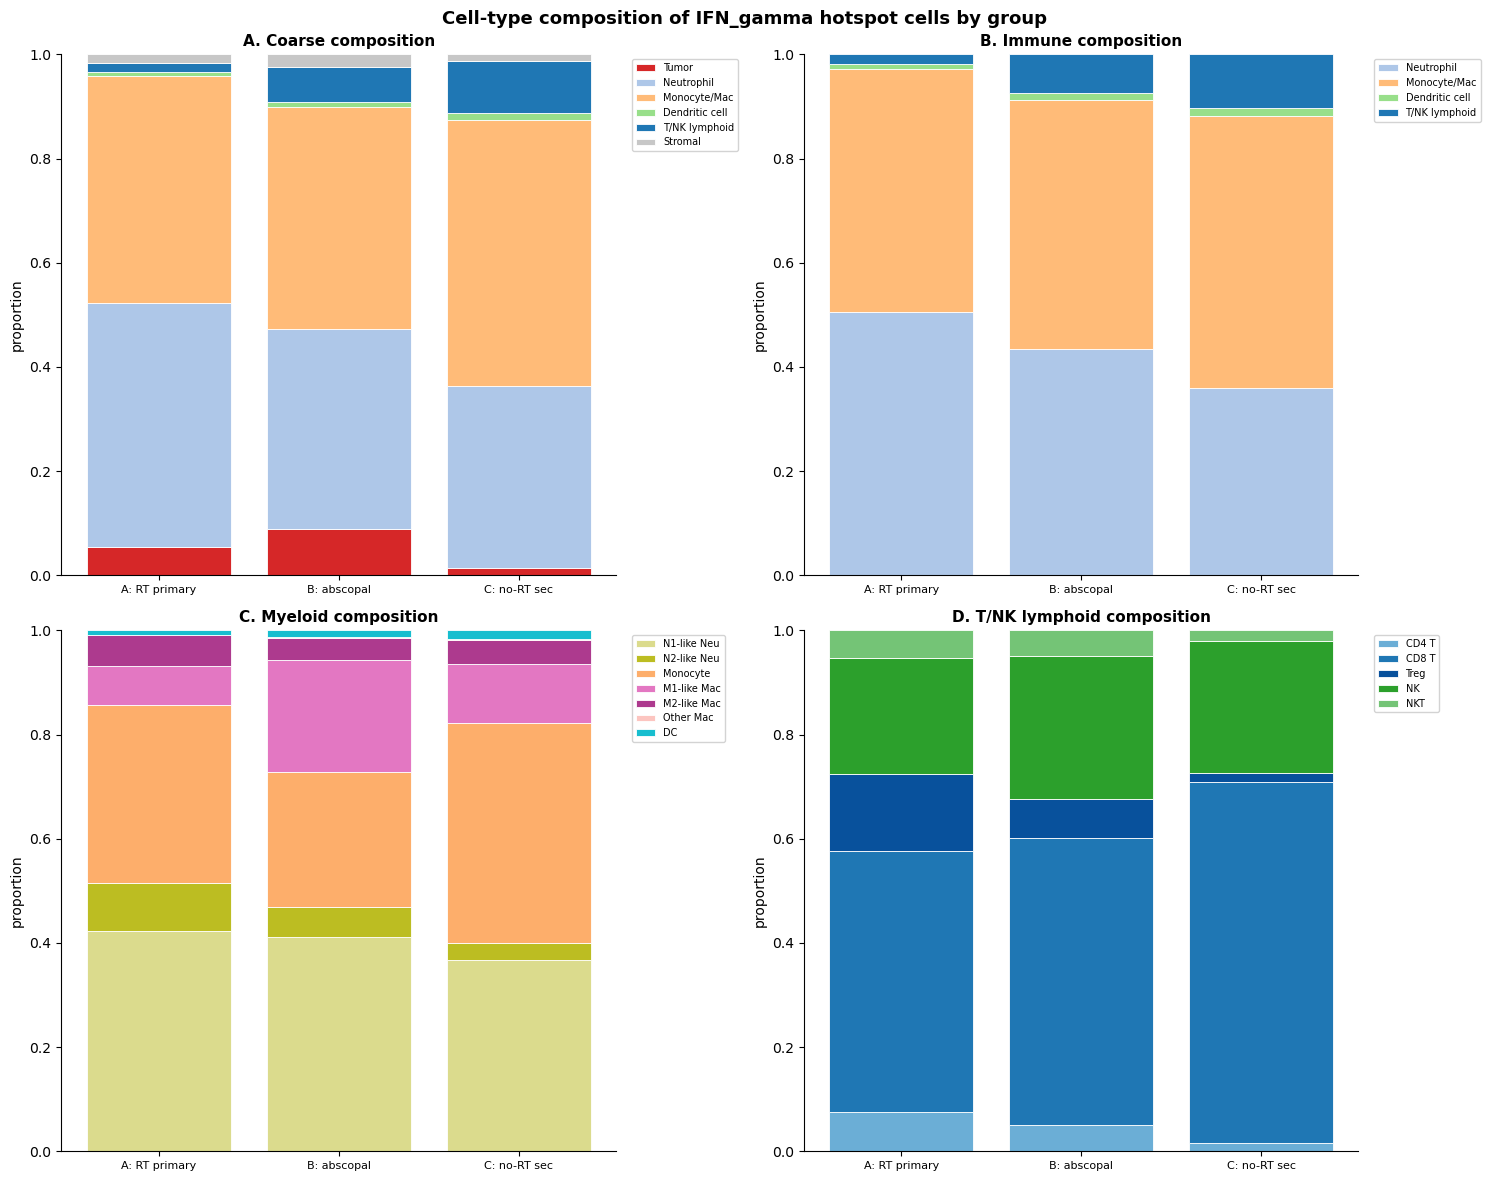

In [35]:
# project cell-type colors if available, else fall back to an auto palette
def _load_cell_colors():
    import sys
    from pathlib import Path
    for base in [Path.cwd(), Path("/Users/janzules/Roselab/Spatial/CAR_T/code"),
                 Path("/home/janzules/spatial/CAR-T/code")]:
        for parent in [base, *base.parents]:
            if (parent / "misc" / "plot_style.py").exists():
                if str(parent) not in sys.path:
                    sys.path.insert(0, str(parent))
                try:
                    from misc.plot_style import CELL_TYPE_COLORS
                    return CELL_TYPE_COLORS
                except Exception:
                    pass
    return {}
C = _load_cell_colors()

GROUP_ORDER = ["A_RT_primary", "B_RT_secondary", "C_noRT_secondary"]
GLAB = {"A_RT_primary": "A: RT primary", "B_RT_secondary": "B: abscopal", "C_noRT_secondary": "C: no-RT sec"}
EXCLUDE = {"B", "Erythrocyte", "Unknown"}

COARSE_GROUPS = {
    "Tumor": ["Cancer_cell"], "Neutrophil": ["N1_like_Neu", "N2_like_Neu"],
    "Monocyte/Mac": ["Classical_Mono", "Nonclassical_Mono", "M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"],
    "Dendritic cell": ["cDC", "pDC"], "T/NK lymphoid": ["CD4_T", "CD8_T", "Treg", "NK", "NKT"],
    "Stromal": ["Endothelial", "Fibroblast"]}
IMMUNE_GROUPS = {k: COARSE_GROUPS[k] for k in ["Neutrophil", "Monocyte/Mac", "Dendritic cell", "T/NK lymphoid"]}
MYELOID_GROUPS = {"N1-like Neu": ["N1_like_Neu"], "N2-like Neu": ["N2_like_Neu"],
    "Monocyte": ["Classical_Mono", "Nonclassical_Mono"], "M1-like Mac": ["M1_like_Mac"],
    "M2-like Mac": ["M2_like_Mac"], "Other Mac": ["Intermediate_Mac"], "DC": ["cDC", "pDC"]}
TNK_GROUPS = {"CD4 T": ["CD4_T"], "CD8 T": ["CD8_T"], "Treg": ["Treg"], "NK": ["NK"], "NKT": ["NKT"]}

COARSE_COLORS = {"Tumor": C.get("Cancer_cell", "#d62728"), "Neutrophil": "#aec7e8",
    "Monocyte/Mac": "#ffbb78", "Dendritic cell": "#98df8a",
    "T/NK lymphoid": C.get("CD8_T", "#1f77b4"), "Stromal": "#c7c7c7"}
IMMUNE_COLORS = {k: COARSE_COLORS[k] for k in IMMUNE_GROUPS}
MYELOID_COLORS = {"N1-like Neu": C.get("N1_like_Neu", "#6baed6"), "N2-like Neu": C.get("N2_like_Neu", "#c5b0d5"),
    "Monocyte": C.get("Classical_Mono", "#fd8d3c"), "M1-like Mac": C.get("M1_like_Mac", "#de2d26"),
    "M2-like Mac": C.get("M2_like_Mac", "#f768a1"), "Other Mac": C.get("Intermediate_Mac", "#c49c94"),
    "DC": C.get("cDC", "#74c476")}
TNK_COLORS = {"CD4 T": C.get("CD4_T", "#aec7e8"), "CD8 T": C.get("CD8_T", "#1f77b4"),
    "Treg": C.get("Treg", "#9467bd"), "NK": C.get("NK", "#2ca02c"), "NKT": C.get("NKT", "#17becf")}

def compute_props(obs, groups, exclude=None):
    exclude = exclude or set()
    ct = obs[~obs[CT_COL].astype(str).isin(exclude)][CT_COL].astype(str).value_counts()
    df = pd.DataFrame([{"group": g, "count": int(sum(ct.get(t, 0) for t in types))}
                       for g, types in groups.items()]).set_index("group")
    tot = df["count"].sum()
    df["proportion"] = df["count"] / tot if tot > 0 else 0.0
    return df

obs_by_group = {g: adata.obs[adata.obs[GROUP_COL] == g] for g in GROUP_ORDER}

def stacked_panel(ax, gdef, colors, title, exclude=None):
    props = {g: compute_props(obs_by_group[g], gdef, exclude) for g in GROUP_ORDER}
    bottoms = {g: 0.0 for g in GROUP_ORDER}
    for cat in gdef:
        for g in GROUP_ORDER:
            v = float(props[g].loc[cat, "proportion"])
            ax.bar(GLAB[g], v, bottom=bottoms[g], color=colors.get(cat, "#999999"),
                   edgecolor="white", linewidth=0.6, label=cat if g == GROUP_ORDER[0] else None)
            bottoms[g] += v
    ax.set_title(title, fontsize=11, fontweight="bold"); ax.set_ylim(0, 1); ax.set_ylabel("proportion")
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=7, framealpha=.85)
    ax.spines[["top", "right"]].set_visible(False)
    return props

fig, axes = plt.subplots(2, 2, figsize=(15, 12)); axf = axes.flatten()
comp_props = {}
comp_props["coarse"]  = stacked_panel(axf[0], COARSE_GROUPS, COARSE_COLORS, "A. Coarse composition", EXCLUDE)
comp_props["immune"]  = stacked_panel(axf[1], IMMUNE_GROUPS, IMMUNE_COLORS, "B. Immune composition")
comp_props["myeloid"] = stacked_panel(axf[2], MYELOID_GROUPS, MYELOID_COLORS, "C. Myeloid composition")
comp_props["tnk"]     = stacked_panel(axf[3], TNK_GROUPS, TNK_COLORS, "D. T/NK lymphoid composition")
fig.suptitle("Cell-type composition of IFN_gamma hotspot cells by group", fontsize=13, fontweight="bold")
fig.tight_layout(); fig.savefig(OUT_DIR / "composition_by_group.png", dpi=150, bbox_inches="tight"); plt.show()


In [40]:
# summary tables: proportion (%) per group for each grouping
for name, gdef in [("Coarse", COARSE_GROUPS), ("Myeloid", MYELOID_GROUPS), ("T/NK", TNK_GROUPS)]:
    tab = pd.DataFrame({GLAB[g]: (compute_props(obs_by_group[g], gdef,
                                  EXCLUDE if name == "Coarse" else None)["proportion"] * 100).round(1)
                        for g in GROUP_ORDER})
    print(f"=== {name} composition (% of cells) ===")
    display(tab)
    tab.to_csv(OUT_DIR / f"composition_{name.replace('/', '')}_by_group.csv")


=== Coarse composition (% of cells) ===


,A: RT primary,B: abscopal,C: no-RT sec
group,,,
Tumor,5.3,8.8,1.5
Neutrophil,47.0,38.5,34.9
Monocyte/Mac,43.5,42.5,50.9
Dendritic cell,0.9,1.1,1.4
T/NK lymphoid,1.7,6.7,10.0
Stromal,1.7,2.4,1.2


=== Myeloid composition (% of cells) ===


,A: RT primary,B: abscopal,C: no-RT sec
group,,,
N1-like Neu,42.3,41.2,36.8
N2-like Neu,9.1,5.7,3.2
Monocyte,34.2,25.9,42.2
M1-like Mac,7.5,21.6,11.4
M2-like Mac,6.0,4.1,4.6
Other Mac,0.0,0.2,0.1
DC,0.9,1.3,1.7


=== T/NK composition (% of cells) ===


,A: RT primary,B: abscopal,C: no-RT sec
group,,,
CD4 T,7.5,5.1,1.5
CD8 T,50.1,55.0,69.4
Treg,14.8,7.5,1.6
NK,22.3,27.4,25.3
NKT,5.3,5.0,2.1


### 10b. Replicate-aware composition (per tissue)

The §10 bars pool all cells (pseudoreplication). Here each **tissue** is one data point, so you can
see whether a compositional shift is consistent across replicates (n=4/2/4) or driven by one
tumor — the honest view given only 2 B tissues.

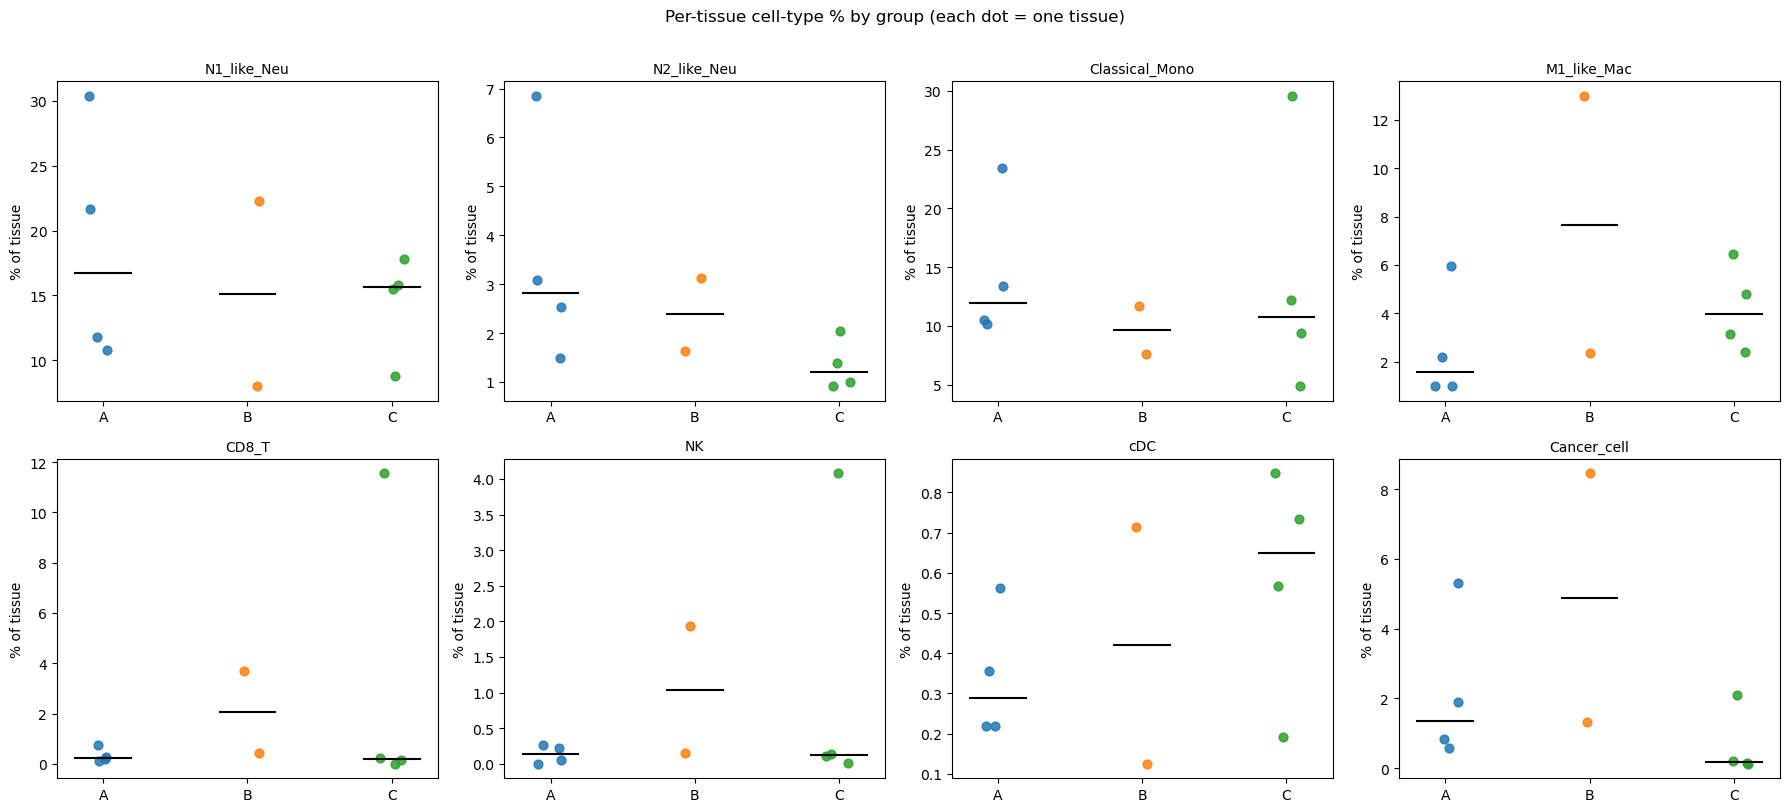

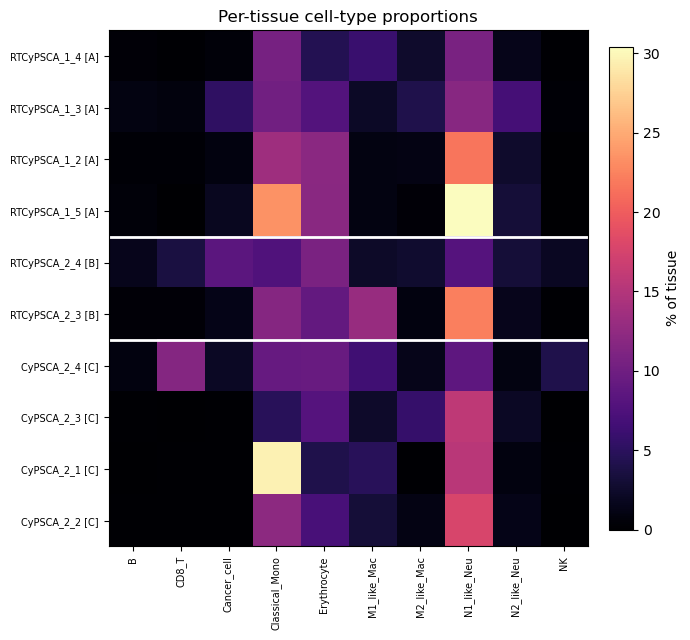

In [41]:
# per-tissue cell-type proportions
counts = (adata.obs.groupby([SAMPLE_COL, CT_COL], observed=True).size()
          .unstack(fill_value=0))
props_t = counts.div(counts.sum(axis=1), axis=0)            # tissues x cell types
t2g = adata.obs.drop_duplicates(SAMPLE_COL).set_index(SAMPLE_COL)[GROUP_COL]
props_t = props_t.loc[[t for t in t2g.index]]              # order
grp_t = t2g.reindex(props_t.index).astype(str)

focus = [c for c in ["N1_like_Neu", "N2_like_Neu", "Classical_Mono", "M1_like_Mac",
                     "CD8_T", "NK", "cDC", "Cancer_cell"] if c in props_t.columns]
gx = {g: i for i, g in enumerate(GROUP_ORDER)}
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 4, figsize=(18, 8));
for ax, ct in zip(axes.ravel(), focus):
    for g in GROUP_ORDER:
        v = props_t.loc[grp_t[grp_t == g].index, ct].values * 100
        ax.scatter(gx[g] + rng.uniform(-.10, .10, len(v)), v, s=40, alpha=.85)
        if len(v): ax.hlines(np.median(v), gx[g]-.2, gx[g]+.2, color="k", lw=1.5)
    ax.set_title(ct, fontsize=10); ax.set_xticks(range(3)); ax.set_xticklabels(["A", "B", "C"])
    ax.set_ylabel("% of tissue")
fig.suptitle("Per-tissue cell-type % by group (each dot = one tissue)", y=1.01, fontsize=12)
fig.tight_layout(); fig.savefig(OUT_DIR / "composition_per_tissue.png", dpi=150, bbox_inches="tight"); plt.show()

# per-tissue proportion heatmap (tissues grouped A/B/C)
order = [t for g in GROUP_ORDER for t in grp_t[grp_t == g].index]
HEATMAP_EXCLUDE = {"Unknown"}   # drop non-informative types that dominate the color scale
show_ct = [c for c in props_t.columns if props_t[c].mean() > 0.005 and c not in HEATMAP_EXCLUDE]
H = props_t.loc[order, show_ct] * 100
fig, ax = plt.subplots(figsize=(0.5*len(show_ct)+2, 0.5*len(order)+1.5))
im = ax.imshow(H.values, cmap="magma", aspect="auto")
ax.set_xticks(range(len(show_ct))); ax.set_xticklabels(show_ct, rotation=90, fontsize=7)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{t} [{ {'A_RT_primary':'A','B_RT_secondary':'B','C_noRT_secondary':'C'}[grp_t[t]] }]" for t in order], fontsize=7)
for b in np.cumsum([ (grp_t==g).sum() for g in GROUP_ORDER ])[:-1]:
    ax.axhline(b-0.5, color="w", lw=2)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="% of tissue")
ax.set_title("Per-tissue cell-type proportions"); fig.tight_layout()
fig.savefig(OUT_DIR / "composition_per_tissue_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
props_t.assign(group=grp_t.values).to_csv(OUT_DIR / "composition_per_tissue.csv")


## 11. Enrichment with gseapy Enrichr (online databases)

Explicit online Enrichr run (mouse libraries) on the B-vs-C cell-level up/down genes, mirroring
`RegionComparison.ipynb`. Complements the §8 result. *Note:* Enrichr libraries are human-symbol
based / 2020–2023 vintage, so they can rank terms differently than the offline ORA over your local
mouse MSigDB v2026.1 GMTs — compare the two, don't expect identical tables.

In [38]:
import gseapy as gp
import time

def enrichr_safe(genes, dbs=ENRICHR_DBS, retries=3):
    genes = list(genes)
    if len(genes) < 5:
        return None
    for a in range(retries):
        try:
            return gp.enrichr(gene_list=genes, gene_sets=dbs, organism="mouse", outdir=None).results
        except Exception as e:
            if "429" in str(e) or "status" in str(e).lower():
                time.sleep(5 * (a + 1)); continue
            print("  Enrichr failed:", e); return None
    return None

dfbc = de_cell[CONTRASTS[0]]
up_g   = dfbc.query("pvals_adj < @PADJ and logfoldchanges >  @LFC").head(N_ENRICH)["names"].tolist()
down_g = dfbc.query("pvals_adj < @PADJ and logfoldchanges < -@LFC").head(N_ENRICH)["names"].tolist()
print(f"Enrichr input: up={len(up_g)}, down={len(down_g)}")

enr_up_gp   = enrichr_safe(up_g)
enr_down_gp = enrichr_safe(down_g)
for lbl, e in [("UP in B vs C", enr_up_gp), ("DOWN in B vs C", enr_down_gp)]:
    print(f"\n=== Enrichr: {lbl} ===")
    if e is None or e.empty:
        print("  (no results / no internet)")
    else:
        sig = e[e["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
        display(sig[["Gene_set", "Term", "Overlap", "Adjusted P-value"]].head(20))


Enrichr input: up=197, down=300

=== Enrichr: UP in B vs C ===


,Gene_set,Term,Overlap,Adjusted P-value
0,MSigDB_Hallmark_2020,KRAS Signaling Up,15/200,5.269514e-08
1,MSigDB_Hallmark_2020,Estrogen Response Early,11/200,6.235944e-05
2,MSigDB_Hallmark_2020,Glycolysis,11/200,6.235944e-05
3,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,9/199,1.074624e-03
4,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,9/200,1.074624e-03
5,MSigDB_Hallmark_2020,p53 Pathway,9/200,1.074624e-03
602,GO_Biological_Process_2023,Regulation Of Apoptotic Process (GO:0042981),21/705,2.688768e-03
601,GO_Biological_Process_2023,Positive Regulation Of Cell Population Prolife...,17/483,2.688768e-03
600,GO_Biological_Process_2023,Regulation Of Epithelial Cell Proliferation (G...,8/91,2.688768e-03
603,GO_Biological_Process_2023,Regulation Of Cell Population Proliferation (G...,22/766,2.688768e-03



=== Enrichr: DOWN in B vs C ===


,Gene_set,Term,Overlap,Adjusted P-value
40,Reactome_2022,Immune System R-HSA-168256,58/1943,0.000178
728,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),15/236,0.002888
727,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,18/320,0.002888
41,Reactome_2022,Signaling By Interleukins R-HSA-449147,20/453,0.005245
42,Reactome_2022,Cytokine Signaling In Immune System R-HSA-1280215,26/702,0.005245
2644,KEGG_2019_Mouse,Cytokine-cytokine receptor interaction,15/292,0.007506
43,Reactome_2022,GPCR Downstream Signaling R-HSA-388396,23/619,0.011226
44,Reactome_2022,Innate Immune System R-HSA-168249,32/1035,0.011590
45,Reactome_2022,MyD88 Deficiency (TLR2/4) R-HSA-5602498,4/17,0.011590
729,GO_Biological_Process_2023,Pattern Recognition Receptor Signaling Pathway...,7/56,0.012582


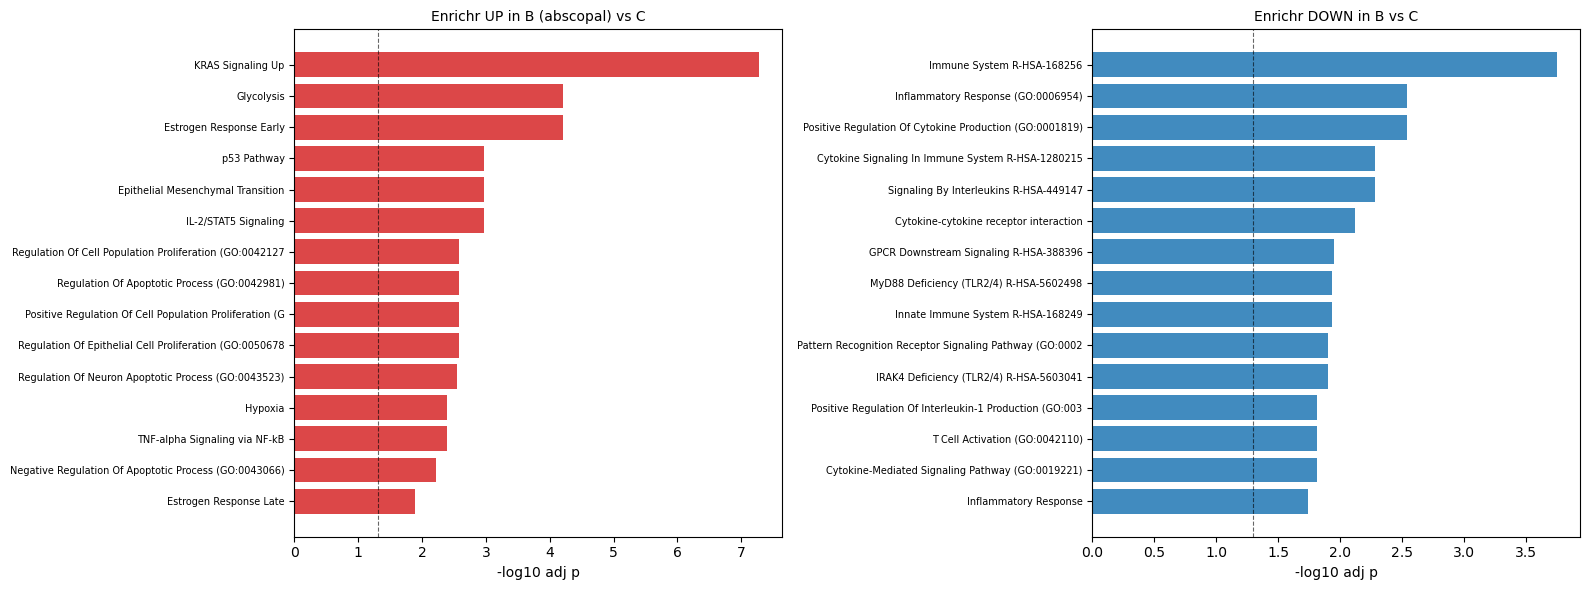

saved Enrichr (gseapy) results


In [39]:
# Enrichr bar plots (top terms each direction)
def enrichr_bar(ax, res, title, color, n=15):
    if res is None or res.empty:
        ax.text(.5, .5, "no results", ha="center", va="center", transform=ax.transAxes); ax.axis("off"); return
    d = res[res["Adjusted P-value"] < 0.05].nsmallest(n, "Adjusted P-value").copy()
    if d.empty:
        ax.text(.5, .5, "no significant terms", ha="center", va="center", transform=ax.transAxes); ax.axis("off"); return
    d["nlp"] = -np.log10(d["Adjusted P-value"].clip(lower=1e-300))
    d["lab"] = d["Term"].str.replace("_", " ").str[:55]
    d = d.sort_values("nlp")
    ax.barh(d["lab"], d["nlp"], color=color, alpha=.85)
    ax.axvline(-np.log10(0.05), ls="--", lw=.8, c="k", alpha=.6)
    ax.set_xlabel("-log10 adj p"); ax.set_title(title, fontsize=10); ax.tick_params(axis="y", labelsize=7)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
enrichr_bar(axes[0], enr_up_gp,   "Enrichr UP in B (abscopal) vs C", "#d62728")
enrichr_bar(axes[1], enr_down_gp, "Enrichr DOWN in B vs C",          "#1f77b4")
fig.tight_layout(); fig.savefig(OUT_DIR / "enrichr_gseapy_B_vs_C.png", dpi=150, bbox_inches="tight"); plt.show()

if enr_up_gp is not None:   enr_up_gp.to_csv(OUT_DIR / "enrichr_gseapy_B_vs_C_UP.csv", index=False)
if enr_down_gp is not None: enr_down_gp.to_csv(OUT_DIR / "enrichr_gseapy_B_vs_C_DOWN.csv", index=False)
print("saved Enrichr (gseapy) results")
